# Customer Segmentation & Churn Pattern Analytics — European Banking

**Objective:** Segmentation-driven analysis of customer churn across France, Spain, and Germany, covering demographic, financial, and engagement dimensions.

**Sections**
1. Data Ingestion & Validation
2. Data Cleaning & Preparation
3. Customer Segmentation Design
4. Churn Distribution Analysis
5. Comparative Demographic Analysis
6. High-Value Customer Churn Analysis
7. Key Performance Indicators (KPIs)
8. Churn Prediction Modeling (with hyperparameter tuning)
9. Summary of Findings


## 1. Data Ingestion & Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('European_Bank.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 10,000 rows x 14 columns


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Data types & missing values
print(df.dtypes)
print()
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete.")


Year                 int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values per column:
None — dataset is complete.


In [3]:
# Validate binary/categorical fields and churn labeling
print("HasCrCard unique values:", sorted(df['HasCrCard'].unique()))
print("IsActiveMember unique values:", sorted(df['IsActiveMember'].unique()))
print("Exited unique values:", sorted(df['Exited'].unique()))
print("Geography categories:", df['Geography'].unique())
print("Gender categories:", df['Gender'].unique())
print()
print("Duplicate CustomerIds:", df['CustomerId'].duplicated().sum())
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("Tenure range:", df['Tenure'].min(), "-", df['Tenure'].max())
print("Balance range:", df['Balance'].min(), "-", round(df['Balance'].max(), 2))


HasCrCard unique values: [np.int64(0), np.int64(1)]
IsActiveMember unique values: [np.int64(0), np.int64(1)]
Exited unique values: [np.int64(0), np.int64(1)]
Geography categories: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str
Gender categories: <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Duplicate CustomerIds: 0
Age range: 18 - 92
Tenure range: 0 - 10
Balance range: 0.0 - 250898.09


**Validation notes:** `HasCrCard`, `IsActiveMember`, and `Exited` are clean binary flags (0/1). `Geography` and `Gender` have no unexpected categories. No duplicate `CustomerId` values. No missing data — the dataset is ready for cleaning with no imputation required.

## 2. Data Cleaning & Preparation

In [4]:
# Remove non-analytical fields
df_clean = df.drop(columns=['Surname'])

# 'Year' is constant (single snapshot year) — keep for reference but drop from analysis frame
print("Year values:", df['Year'].unique())
df_clean = df_clean.drop(columns=['Year'])

# Convert categorical/binary fields for grouping and readability
df_clean['Gender'] = df_clean['Gender'].astype('category')
df_clean['Geography'] = df_clean['Geography'].astype('category')
df_clean['HasCrCard_Label'] = df_clean['HasCrCard'].map({1: 'Has Card', 0: 'No Card'})
df_clean['IsActiveMember_Label'] = df_clean['IsActiveMember'].map({1: 'Active', 0: 'Inactive'})
df_clean['Exited_Label'] = df_clean['Exited'].map({1: 'Churned', 0: 'Retained'})

df_clean.head()


Year values: [2025]


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasCrCard_Label,IsActiveMember_Label,Exited_Label
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Has Card,Active,Churned
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,No Card,Active,Retained
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Has Card,Inactive,Churned
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0,No Card,Inactive,Retained
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Has Card,Active,Retained


## 3. Customer Segmentation Design

Creating the five segmentation dimensions specified in the project brief.

In [5]:
# Age segmentation
age_bins = [0, 30, 45, 60, 150]
age_labels = ['<30', '30-45', '46-60', '60+']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=age_bins, labels=age_labels, right=True)
# Adjust boundary so 46-60 label matches 46-60 inclusive (pandas cut is right-inclusive by default,
# so bins [0,30,45,60,150] with right=True gives (30,45] and (45,60] -> relabel boundary at 45/46 correctly)

# Credit score bands
credit_bins = [0, 580, 700, 1000]
credit_labels = ['Low (<580)', 'Medium (580-700)', 'High (>700)']
df_clean['CreditScoreBand'] = pd.cut(df_clean['CreditScore'], bins=credit_bins, labels=credit_labels)

# Tenure groups
def tenure_group(t):
    if t <= 2:
        return 'New (0-2 yrs)'
    elif t <= 6:
        return 'Mid-term (3-6 yrs)'
    else:
        return 'Long-term (7+ yrs)'
df_clean['TenureGroup'] = df_clean['Tenure'].apply(tenure_group)
df_clean['TenureGroup'] = pd.Categorical(df_clean['TenureGroup'],
    categories=['New (0-2 yrs)', 'Mid-term (3-6 yrs)', 'Long-term (7+ yrs)'], ordered=True)

# Balance segments
def balance_segment(b):
    if b == 0:
        return 'Zero-balance'
    elif b < 100000:
        return 'Low-balance (<100K)'
    else:
        return 'High-balance (>=100K)'
df_clean['BalanceSegment'] = df_clean['Balance'].apply(balance_segment)
df_clean['BalanceSegment'] = pd.Categorical(df_clean['BalanceSegment'],
    categories=['Zero-balance', 'Low-balance (<100K)', 'High-balance (>=100K)'], ordered=True)

seg_cols = ['Geography', 'AgeGroup', 'CreditScoreBand', 'TenureGroup', 'BalanceSegment']
for c in seg_cols:
    print(f"--- {c} ---")
    print(df_clean[c].value_counts().sort_index())
    print()


--- Geography ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

--- AgeGroup ---
AgeGroup
<30      1968
30-45    5921
46-60    1647
60+       464
Name: count, dtype: int64

--- CreditScoreBand ---
CreditScoreBand
Low (<580)          2393
Medium (580-700)    4491
High (>700)         3116
Name: count, dtype: int64

--- TenureGroup ---
TenureGroup
New (0-2 yrs)         2496
Mid-term (3-6 yrs)    3977
Long-term (7+ yrs)    3527
Name: count, dtype: int64

--- BalanceSegment ---
BalanceSegment
Zero-balance             3617
Low-balance (<100K)      1584
High-balance (>=100K)    4799
Name: count, dtype: int64



## 4. Churn Distribution Analysis

In [6]:
overall_churn_rate = df_clean['Exited'].mean()
print(f"Overall churn rate: {overall_churn_rate:.2%}")
print(f"Churned customers: {df_clean['Exited'].sum():,} of {len(df_clean):,}")


Overall churn rate: 20.37%
Churned customers: 2,037 of 10,000


In [7]:
def segment_churn_table(df, col):
    tbl = df.groupby(col, observed=True).agg(
        Customers=('Exited', 'count'),
        Churned=('Exited', 'sum'),
        ChurnRate=('Exited', 'mean')
    )
    tbl['ShareOfBase'] = tbl['Customers'] / len(df)
    tbl['ShareOfChurners'] = tbl['Churned'] / df['Exited'].sum()
    return tbl.sort_values('ChurnRate', ascending=False)

for col in seg_cols:
    print(f"=== Churn rate by {col} ===")
    display(segment_churn_table(df_clean, col).style.format({
        'ChurnRate': '{:.2%}', 'ShareOfBase': '{:.1%}', 'ShareOfChurners': '{:.1%}'
    }))


=== Churn rate by Geography ===


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
Geography,,,,,
Germany,2509,814,32.44%,25.1%,40.0%
Spain,2477,413,16.67%,24.8%,20.3%
France,5014,810,16.15%,50.1%,39.8%


=== Churn rate by AgeGroup ===


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
AgeGroup,,,,,
46-60,1647,842,51.12%,16.5%,41.3%
60+,464,115,24.78%,4.6%,5.6%
30-45,5921,932,15.74%,59.2%,45.8%
<30,1968,148,7.52%,19.7%,7.3%


=== Churn rate by CreditScoreBand ===


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
CreditScoreBand,,,,,
Low (<580),2393,530,22.15%,23.9%,26.0%
High (>700),3116,619,19.87%,31.2%,30.4%
Medium (580-700),4491,888,19.77%,44.9%,43.6%


=== Churn rate by TenureGroup ===


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
TenureGroup,,,,,
New (0-2 yrs),2496,528,21.15%,25.0%,25.9%
Mid-term (3-6 yrs),3977,821,20.64%,39.8%,40.3%
Long-term (7+ yrs),3527,688,19.51%,35.3%,33.8%


=== Churn rate by BalanceSegment ===


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
BalanceSegment,,,,,
High-balance (>=100K),4799,1211,25.23%,48.0%,59.5%
Low-balance (<100K),1584,326,20.58%,15.8%,16.0%
Zero-balance,3617,500,13.82%,36.2%,24.5%


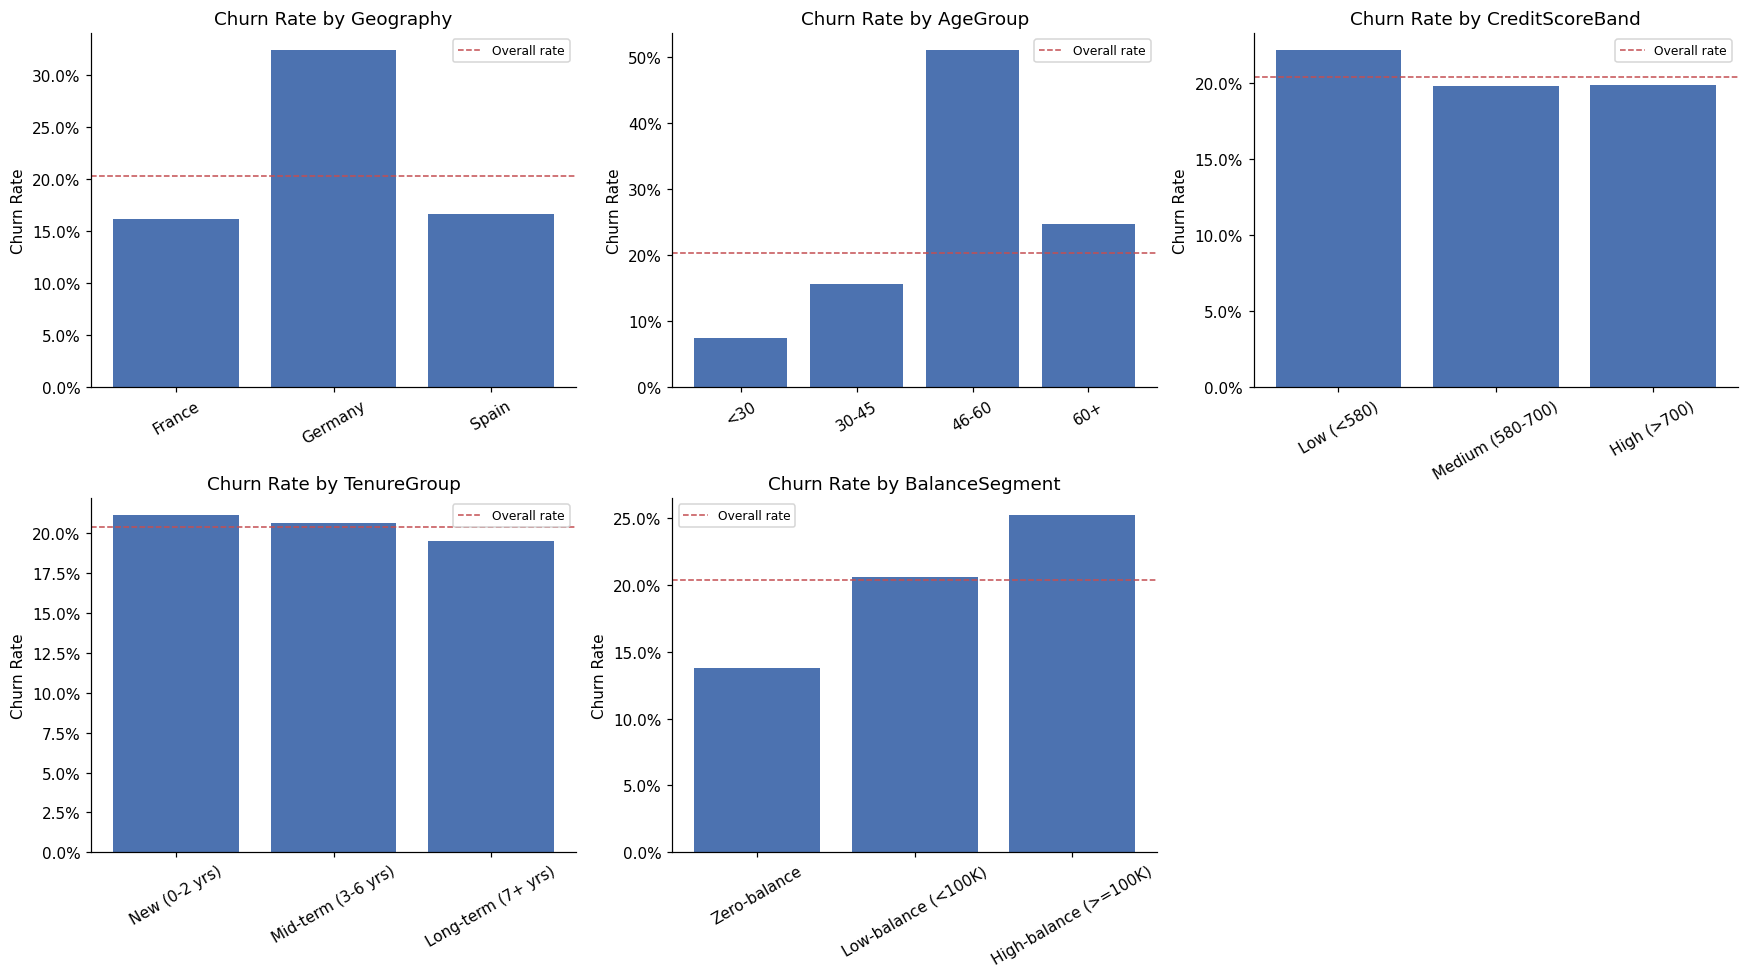

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, seg_cols):
    tbl = segment_churn_table(df_clean, col)['ChurnRate'].sort_index()
    bars = ax.bar(tbl.index.astype(str), tbl.values, color='#4C72B0')
    ax.axhline(overall_churn_rate, color='#C44E52', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('churn_by_segment.png', bbox_inches='tight')
plt.show()


In [9]:
# Churned vs retained profile comparison
profile_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
profile_compare = df_clean.groupby('Exited_Label')[profile_cols].mean().T
profile_compare['Difference'] = profile_compare['Churned'] - profile_compare['Retained']
profile_compare


Exited_Label,Churned,Retained,Difference
CreditScore,645.351497,651.853196,-6.501699
Age,44.837997,37.408389,7.429608
Tenure,4.932744,5.033279,-0.100535
Balance,91108.539337,72745.296779,18363.242558
NumOfProducts,1.475209,1.544267,-0.069059
EstimatedSalary,101465.677531,99738.391772,1727.285759


**Key read:** the profile comparison above highlights which numeric attributes differ most between churned and retained customers — a first signal of what drives the segmentation-level churn rate differences seen above.

## 5. Comparative Demographic Analysis

In [10]:
# Gender-based churn differences
gender_churn = segment_churn_table(df_clean, 'Gender')
print("Churn by Gender:")
display(gender_churn.style.format({'ChurnRate': '{:.2%}', 'ShareOfBase': '{:.1%}', 'ShareOfChurners': '{:.1%}'}))


Churn by Gender:


,Customers,Churned,ChurnRate,ShareOfBase,ShareOfChurners
Gender,,,,,
Female,4543,1139,25.07%,45.4%,55.9%
Male,5457,898,16.46%,54.6%,44.1%


Churn rate — Geography x Age Group:


AgeGroup,<30,30-45,46-60,60+
Geography,,,,
France,4.91%,12.35%,45.79%,19.91%
Germany,12.36%,26.09%,67.33%,38.94%
Spain,8.60%,12.53%,40.66%,20.83%


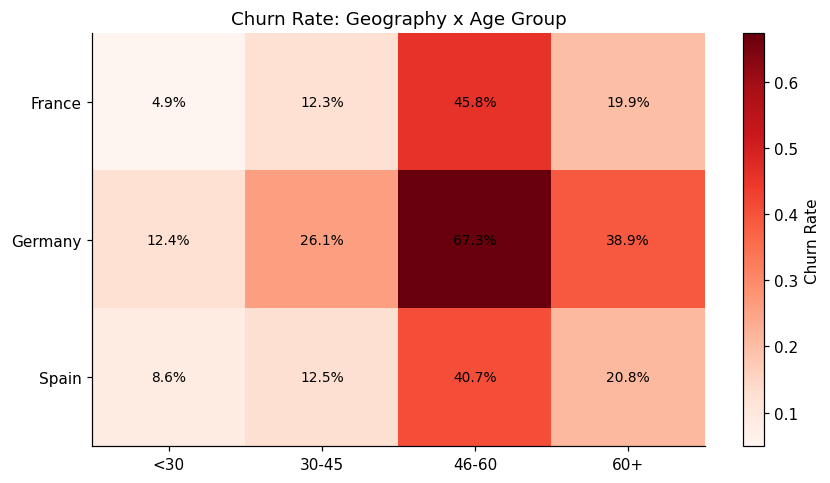

In [11]:
# Geography x Age interaction
geo_age = df_clean.groupby(['Geography', 'AgeGroup'], observed=True)['Exited'].mean().unstack()
print("Churn rate — Geography x Age Group:")
display(geo_age.style.format('{:.2%}').background_gradient(cmap='Reds', axis=None))

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(geo_age.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(geo_age.columns))); ax.set_xticklabels(geo_age.columns)
ax.set_yticks(range(len(geo_age.index))); ax.set_yticklabels(geo_age.index)
for i in range(geo_age.shape[0]):
    for j in range(geo_age.shape[1]):
        ax.text(j, i, f"{geo_age.values[i,j]:.1%}", ha='center', va='center', fontsize=9)
ax.set_title('Churn Rate: Geography x Age Group')
plt.colorbar(im, ax=ax, label='Churn Rate')
plt.tight_layout()
plt.savefig('geo_age_heatmap.png', bbox_inches='tight')
plt.show()


In [12]:
# Financial stability vs churn — active membership and product count as engagement proxies
engagement = df_clean.groupby(['IsActiveMember_Label', 'NumOfProducts'], observed=True)['Exited'].agg(['count', 'mean'])
engagement.columns = ['Customers', 'ChurnRate']
print("Churn by Activity Status x Number of Products:")
display(engagement.style.format({'ChurnRate': '{:.2%}'}))


Churn by Activity Status x Number of Products:


## 6. High-Value Customer Churn Analysis

In [13]:
# Define high-value customers: top quartile by Balance OR top quartile by EstimatedSalary
balance_q75 = df_clean['Balance'].quantile(0.75)
salary_q75 = df_clean['EstimatedSalary'].quantile(0.75)
df_clean['HighValue'] = (df_clean['Balance'] >= balance_q75) | (df_clean['EstimatedSalary'] >= salary_q75)

hv_churn_rate = df_clean.loc[df_clean['HighValue'], 'Exited'].mean()
overall_rate = df_clean['Exited'].mean()
print(f"High-value customer threshold — Balance >= {balance_q75:,.0f} OR Salary >= {salary_q75:,.0f}")
print(f"High-value customers: {df_clean['HighValue'].sum():,} ({df_clean['HighValue'].mean():.1%} of base)")
print(f"High-value churn rate: {hv_churn_rate:.2%}  (vs overall {overall_rate:.2%})")


High-value customer threshold — Balance >= 127,644 OR Salary >= 149,388
High-value customers: 4,351 (43.5% of base)
High-value churn rate: 22.27%  (vs overall 20.37%)


In [14]:
# Revenue risk from churn: balance lost to churned customers
total_balance = df_clean['Balance'].sum()
churned_balance = df_clean.loc[df_clean['Exited'] == 1, 'Balance'].sum()
hv_churned_balance = df_clean.loc[(df_clean['Exited'] == 1) & (df_clean['HighValue']), 'Balance'].sum()

print(f"Total balance across all customers: {total_balance:,.0f}")
print(f"Balance held by churned customers: {churned_balance:,.0f} ({churned_balance/total_balance:.1%} of total balance)")
print(f"Balance held by churned HIGH-VALUE customers: {hv_churned_balance:,.0f} ({hv_churned_balance/total_balance:.1%} of total balance)")


Total balance across all customers: 764,858,893
Balance held by churned customers: 185,588,095 (24.3% of total balance)
Balance held by churned HIGH-VALUE customers: 113,353,534 (14.8% of total balance)


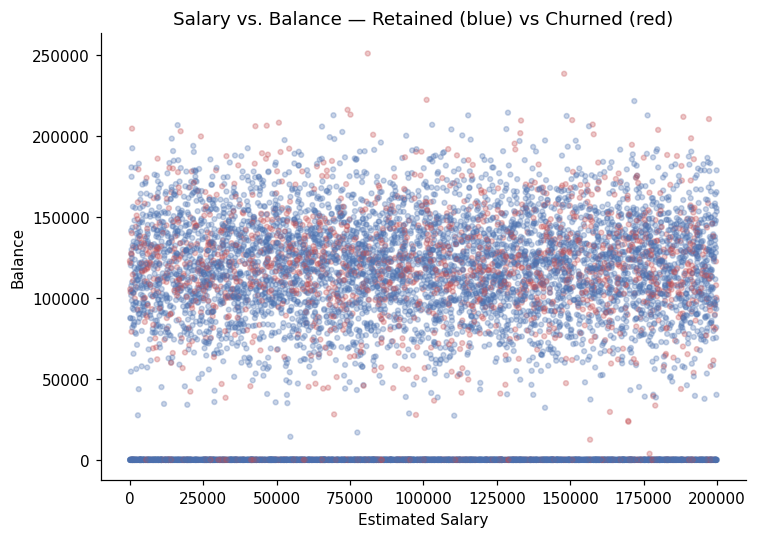

In [15]:
# Salary vs balance pattern among churners
fig, ax = plt.subplots(figsize=(7, 5))
colors = df_clean['Exited'].map({0: '#4C72B0', 1: '#C44E52'})
ax.scatter(df_clean['EstimatedSalary'], df_clean['Balance'], c=colors, alpha=0.3, s=10)
ax.set_xlabel('Estimated Salary')
ax.set_ylabel('Balance')
ax.set_title('Salary vs. Balance — Retained (blue) vs Churned (red)')
plt.tight_layout()
plt.savefig('salary_vs_balance.png', bbox_inches='tight')
plt.show()


## 7. Key Performance Indicators (KPIs)

In [16]:
kpis = {}

# Overall Churn Rate
kpis['Overall Churn Rate'] = df_clean['Exited'].mean()

# High-Value Churn Ratio (high-value churners / all churners)
kpis['High-Value Churn Ratio (share of all churners)'] = (
    df_clean.loc[(df_clean['Exited']==1) & (df_clean['HighValue'])].shape[0] / df_clean['Exited'].sum()
)

# Geographic Risk Index (relative to overall rate; >1 = higher risk than average)
geo_index = (segment_churn_table(df_clean, 'Geography')['ChurnRate'] / overall_rate).round(2)

# Engagement Drop Indicator (churn rate gap: inactive vs active members)
active_churn = df_clean.loc[df_clean['IsActiveMember']==1, 'Exited'].mean()
inactive_churn = df_clean.loc[df_clean['IsActiveMember']==0, 'Exited'].mean()
kpis['Engagement Drop Indicator (inactive minus active churn rate, pp)'] = (inactive_churn - active_churn) * 100

print("=== KPI Summary ===")
for k, v in kpis.items():
    if 'Rate' in k or 'Ratio' in k:
        print(f"{k}: {v:.2%}")
    else:
        print(f"{k}: {v:.2f}")

print()
print("Geographic Risk Index (churn rate / overall churn rate):")
print(geo_index)


=== KPI Summary ===
Overall Churn Rate: 20.37%
High-Value Churn Ratio (share of all churners): 47.57%
Engagement Drop Indicator (inactive minus active churn rate, pp): 12.58

Geographic Risk Index (churn rate / overall churn rate):
Geography
Germany    1.59
Spain      0.82
France     0.79
Name: ChurnRate, dtype: float64


In [17]:
kpi_summary_df = pd.DataFrame({
    'KPI': ['Overall Churn Rate', 'High-Value Churn Ratio (of all churners)',
            'Engagement Drop Indicator (pp)', 'Active Member Churn Rate', 'Inactive Member Churn Rate'],
    'Value': [f"{kpis['Overall Churn Rate']:.2%}",
              f"{kpis['High-Value Churn Ratio (share of all churners)']:.2%}",
              f"{kpis['Engagement Drop Indicator (inactive minus active churn rate, pp)']:.1f} pp",
              f"{active_churn:.2%}", f"{inactive_churn:.2%}"]
})
kpi_summary_df


,KPI,Value
0,Overall Churn Rate,20.37%
1,High-Value Churn Ratio (of all churners),47.57%
2,Engagement Drop Indicator (pp),12.6 pp
3,Active Member Churn Rate,14.27%
4,Inactive Member Churn Rate,26.85%


## 8. Churn Prediction Modeling

Building and comparing several supervised classification models to predict `Exited` (churn) from customer attributes, then hyperparameter-tuning the strongest candidates before finalizing a model. This produces:
- A side-by-side baseline comparison of model families (linear, tree-based, boosted, margin-based)
- Cross-validated hyperparameter tuning of the top tree-based candidates
- A final model that scores each customer's churn probability, for proactive retention targeting
- Feature importance ranking — which factors matter most for prediction


### 8.1 Feature Preparation

In [18]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)
from scipy.stats import randint, uniform

# Features: raw drivers of churn (avoid leaking engineered labels derived from Exited itself)
numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

X = df_clean[numeric_features + categorical_features].copy()
y = df_clean['Exited'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]:,}   Test size: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean():.2%}   Test churn rate: {y_test.mean():.2%}")


Train size: 8,000   Test size: 2,000
Train churn rate: 20.38%   Test churn rate: 20.35%


### 8.2 Baseline Model Pipelines

Comparing six model families with default/reasonable-default hyperparameters: a linear baseline (Logistic Regression), a single tree (Decision Tree), two ensemble methods (Random Forest, Gradient Boosting), a boosted-tree library (XGBoost), and a margin-based classifier (SVM). All use class-balanced weighting since churn is only ~20% of the base.

In [19]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='if_binary'), categorical_features)
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # for XGBoost's imbalance handling

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                             class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                              random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
}

pipelines = {}
for name, clf in base_models.items():
    pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


Trained: Gradient Boosting
Trained: XGBoost


Trained: SVM (RBF)


### 8.3 Baseline Model Evaluation

In [20]:
def evaluate(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }, y_pred, y_proba

eval_results, predictions, probabilities = {}, {}, {}
for name, pipe in pipelines.items():
    metrics, pred, proba = evaluate(pipe, name, X_test, y_test)
    eval_results[name] = metrics
    predictions[name] = pred
    probabilities[name] = proba

results_df = pd.DataFrame(list(eval_results.values())).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.style.format('{:.3f}').background_gradient(cmap='Greens', subset=['ROC-AUC'])


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting,0.871,0.794,0.491,0.607,0.870
XGBoost,0.800,0.507,0.737,0.601,0.868
Random Forest,0.814,0.532,0.717,0.611,0.862
SVM (RBF),0.787,0.485,0.735,0.585,0.856
Decision Tree,0.761,0.451,0.784,0.572,0.842
Logistic Regression,0.714,0.387,0.700,0.499,0.777


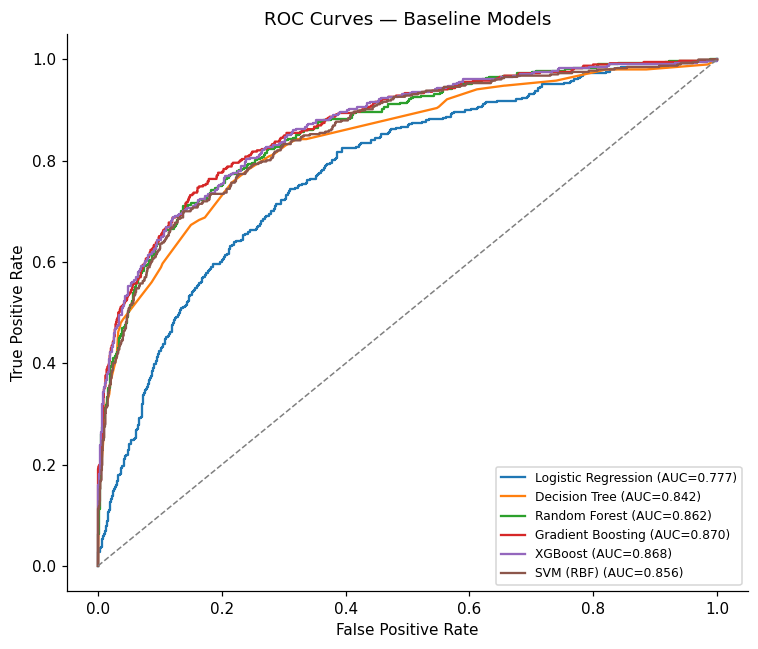

In [21]:
# ROC curves for all baseline models
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Baseline Models')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('roc_curve_baseline.png', bbox_inches='tight')
plt.show()


### 8.4 Hyperparameter Tuning

The three tree-based ensembles (Random Forest, Gradient Boosting, XGBoost) are the strongest and most tunable candidates from the baseline pass. Each is tuned with **`RandomizedSearchCV`** (5-fold cross-validation, 25 sampled parameter combinations, scored on ROC-AUC) rather than an exhaustive grid search, since randomized search covers a wide hyperparameter space in a fraction of the time.

In [22]:
param_distributions = {
    'Random Forest': {
        'model__n_estimators': randint(150, 600),
        'model__max_depth': randint(4, 16),
        'model__min_samples_leaf': randint(2, 30),
        'model__min_samples_split': randint(2, 20),
        'model__max_features': ['sqrt', 'log2', None],
    },
    'Gradient Boosting': {
        'model__n_estimators': randint(100, 400),
        'model__max_depth': randint(2, 6),
        'model__learning_rate': uniform(0.01, 0.19),
        'model__subsample': uniform(0.6, 0.4),
        'model__min_samples_leaf': randint(5, 40),
    },
    'XGBoost': {
        'model__n_estimators': randint(100, 500),
        'model__max_depth': randint(2, 8),
        'model__learning_rate': uniform(0.01, 0.19),
        'model__subsample': uniform(0.6, 0.4),
        'model__colsample_bytree': uniform(0.6, 0.4),
        'model__min_child_weight': randint(1, 10),
    },
}

tuning_candidates = ['Random Forest', 'Gradient Boosting', 'XGBoost']
tuned_pipelines = {}
tuned_rows = []

for name in tuning_candidates:
    search = RandomizedSearchCV(
        estimator=pipelines[name],
        param_distributions=param_distributions[name],
        n_iter=15, cv=3, scoring='roc_auc',
        random_state=42, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_

    metrics, pred, proba = evaluate(search.best_estimator_, f'{name} (Tuned)', X_test, y_test)
    metrics['CV ROC-AUC'] = search.best_score_
    tuned_rows.append(metrics)

    print(f"{name}: best CV ROC-AUC = {search.best_score_:.3f} | test ROC-AUC = {metrics['ROC-AUC']:.3f}")
    print(f"  Best params: {search.best_params_}\n")

tuned_results_df = pd.DataFrame(tuned_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
tuned_results_df.style.format('{:.3f}')


Random Forest: best CV ROC-AUC = 0.862 | test ROC-AUC = 0.861
  Best params: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 13, 'model__n_estimators': 463}



Gradient Boosting: best CV ROC-AUC = 0.865 | test ROC-AUC = 0.868
  Best params: {'model__learning_rate': np.float64(0.014381860757868993), 'model__max_depth': 4, 'model__min_samples_leaf': 32, 'model__n_estimators': 287, 'model__subsample': np.float64(0.7465447373174767)}



XGBoost: best CV ROC-AUC = 0.868 | test ROC-AUC = 0.869
  Best params: {'model__colsample_bytree': np.float64(0.908897907718663), 'model__learning_rate': np.float64(0.04775597949149276), 'model__max_depth': 4, 'model__min_child_weight': 3, 'model__n_estimators': 180, 'model__subsample': np.float64(0.88453678109946)}



,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC
Model,,,,,,
XGBoost (Tuned),0.803,0.511,0.762,0.611,0.869,0.868
Gradient Boosting (Tuned),0.869,0.808,0.464,0.590,0.868,0.865
Random Forest (Tuned),0.849,0.630,0.619,0.625,0.861,0.862


In [23]:
# Tuned vs. untuned comparison for the three tuned model families
compare_rows = []
for name in tuning_candidates:
    before = results_df.loc[name]
    after = tuned_results_df.loc[f'{name} (Tuned)']
    compare_rows.append({'Model': name, 'ROC-AUC (Before)': before['ROC-AUC'], 'ROC-AUC (After)': after['ROC-AUC'],
                          'Recall (Before)': before['Recall'], 'Recall (After)': after['Recall']})
tuning_impact_df = pd.DataFrame(compare_rows).set_index('Model')
tuning_impact_df['ROC-AUC Change'] = tuning_impact_df['ROC-AUC (After)'] - tuning_impact_df['ROC-AUC (Before)']
tuning_impact_df.style.format('{:.3f}')


,ROC-AUC (Before),ROC-AUC (After),Recall (Before),Recall (After),ROC-AUC Change
Model,,,,,
Random Forest,0.862,0.861,0.717,0.619,-0.000
Gradient Boosting,0.870,0.868,0.491,0.464,-0.002
XGBoost,0.868,0.869,0.737,0.762,0.001


In [24]:
# Final model selection: compare the untouched models (Logistic Regression, Decision Tree, SVM)
# against the tuned tree ensembles, and pick the overall best by test ROC-AUC.
final_candidates = {name: pipe for name, pipe in pipelines.items() if name not in tuning_candidates}
final_candidates.update({f'{name} (Tuned)': pipe for name, pipe in tuned_pipelines.items()})

final_predictions, final_probabilities, final_scores = {}, {}, {}
for name, pipe in final_candidates.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    final_predictions[name] = pred
    final_probabilities[name] = proba
    final_scores[name] = roc_auc_score(y_test, proba)

best_model_name = max(final_scores, key=final_scores.get)
best_model = final_candidates[best_model_name]
print(f"Final selected model: {best_model_name}  (test ROC-AUC = {final_scores[best_model_name]:.3f})")


Final selected model: XGBoost (Tuned)  (test ROC-AUC = 0.869)


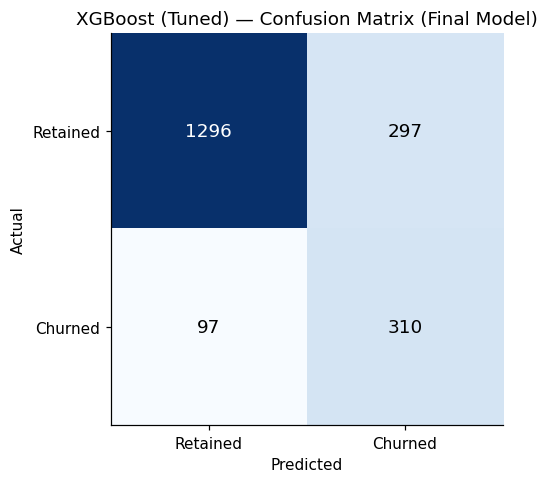

In [25]:
# Confusion matrix for the final selected (tuned, where applicable) model
fig, ax = plt.subplots(figsize=(5, 4.5))
cm = confusion_matrix(y_test, final_predictions[best_model_name])
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'{best_model_name} — Confusion Matrix (Final Model)')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Retained', 'Churned'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Retained', 'Churned'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', bbox_inches='tight')
plt.show()


### 8.5 Feature Importance

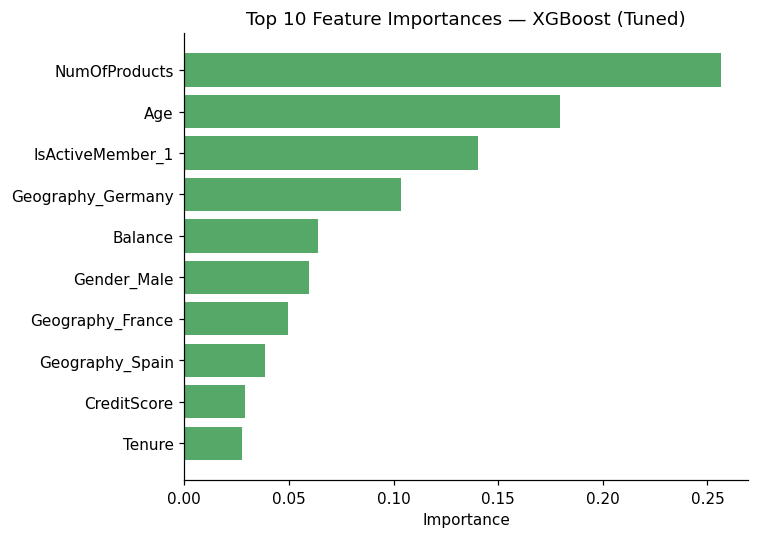

,Feature,Importance
0,NumOfProducts,0.256584
1,Age,0.179344
2,IsActiveMember_1,0.140331
3,Geography_Germany,0.103613
4,Balance,0.063956
5,Gender_Male,0.059810
6,Geography_France,0.049752
7,Geography_Spain,0.038698
8,CreditScore,0.028790
9,Tenure,0.027585


In [26]:
# Feature importance from the final selected model (falls back to permutation importance if the
# model has no native importances, e.g. SVM or Logistic Regression)
feature_names = (numeric_features +
                  list(best_model.named_steps['preprocess']
                       .named_transformers_['cat'].get_feature_names_out(categorical_features)))

fitted_estimator = best_model.named_steps['model']
if hasattr(fitted_estimator, 'feature_importances_'):
    importances = fitted_estimator.feature_importances_
elif hasattr(fitted_estimator, 'coef_'):
    importances = abs(fitted_estimator.coef_[0])
else:
    from sklearn.inspection import permutation_importance
    X_test_transformed = best_model.named_steps['preprocess'].transform(X_test)
    perm = permutation_importance(fitted_estimator, X_test_transformed, y_test, n_repeats=10, random_state=42)
    importances = perm.importances_mean

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(
    'Importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(fi_df['Feature'][:10][::-1], fi_df['Importance'][:10][::-1], color='#55A868')
ax.set_title(f'Top 10 Feature Importances — {best_model_name}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

fi_df.head(10)


### 8.6 Churn Risk Scoring — Full Customer Base

In [27]:
# Score every customer using the final tuned model to produce a retention worklist.
df_clean['ChurnProbability'] = best_model.predict_proba(X)[:, 1]

def risk_tier(p):
    if p >= 0.7:
        return 'High Risk'
    elif p >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_clean['ChurnRiskTier'] = df_clean['ChurnProbability'].apply(risk_tier)

risk_summary = df_clean.groupby('ChurnRiskTier', observed=True).agg(
    Customers=('CustomerId', 'count'),
    ActualChurnRate=('Exited', 'mean'),
    AvgBalance=('Balance', 'mean')
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])
risk_summary.style.format({'ActualChurnRate': '{:.2%}', 'AvgBalance': '{:,.0f}'})


,Customers,ActualChurnRate,AvgBalance
ChurnRiskTier,,,
High Risk,1654,72.79%,"90,984"
Medium Risk,2160,26.06%,"96,141"
Low Risk,6186,4.36%,"65,746"


In [28]:
# Export a prioritized retention worklist: highest churn-probability customers, with key context
retention_worklist = df_clean.sort_values('ChurnProbability', ascending=False)[
    ['CustomerId', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
     'IsActiveMember_Label', 'ChurnProbability', 'ChurnRiskTier', 'Exited_Label']
]
retention_worklist.to_csv('churn_risk_scores.csv', index=False)
print(f"Model used for scoring: {best_model_name}")
print(f"Exported churn_risk_scores.csv — {len(retention_worklist):,} customers scored and ranked.")
retention_worklist.head(10)


Model used for scoring: XGBoost (Tuned)
Exported churn_risk_scores.csv — 10,000 customers scored and ranked.


,CustomerId,Geography,Age,Tenure,Balance,NumOfProducts,IsActiveMember_Label,ChurnProbability,ChurnRiskTier,Exited_Label
2614,15640846,Germany,58,3,106458.31,4,Inactive,0.997830,High Risk,Churned
8923,15570002,Germany,55,8,118772.71,4,Inactive,0.997657,High Risk,Churned
6279,15608338,Spain,55,9,117294.12,4,Inactive,0.996899,High Risk,Churned
6255,15589017,Germany,55,4,111362.76,3,Inactive,0.996752,High Risk,Churned
70,15703793,Germany,58,2,133745.44,4,Inactive,0.996668,High Risk,Churned
4013,15653776,Germany,57,1,162082.31,4,Inactive,0.996308,High Risk,Churned
1962,15692416,Spain,52,8,143542.36,3,Inactive,0.996296,High Risk,Churned
1265,15662291,France,55,8,116973.26,3,Inactive,0.996102,High Risk,Churned
5950,15806808,Germany,57,8,112281.60,3,Inactive,0.996056,High Risk,Churned
963,15731815,Spain,63,4,96134.11,3,Inactive,0.996013,High Risk,Churned


**Model notes for the write-up:** report the baseline comparison (8.3), the tuning impact table (8.4) — note whether tuning meaningfully improved ROC-AUC/Recall or mainly confirmed the untuned choice — and the final selected model with its test-set metrics. With an imbalanced ~20% churn base, lead with Recall and ROC-AUC rather than Accuracy alone. Use the top drivers from 8.5 and the risk-tier table from 8.6 as the basis for the dashboard's "high-value customer explorer" and the retention targeting recommendation in the research paper.

## 9. Summary of Findings

*(Run the notebook top-to-bottom on the full dataset, then fill in the bullets below with the numbers your cells produced — these feed directly into the research paper and executive summary.)*

- Overall churn rate: **see Section 4**
- Highest-risk segments: **see Section 4 bar charts**
- Geography x age interaction: **see Section 5 heatmap**
- High-value customer exposure: **see Section 6**
- KPI values: **see Section 7 table**